In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd

from PIL import Image

from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

PyTorch version: 2.13.0+cpu
Using CPU


In [3]:
PROJECT_ROOT = Path.cwd()

# If notebook is inside Distribution checking/I-HAZE,
# find the project root automatically.

while not (
    (PROJECT_ROOT / "data").exists()
    and
    (PROJECT_ROOT / "Distribution checking").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent


IHAZE_PATCH_DIR = (
    PROJECT_ROOT
    / "Distribution checking"
    / "I-HAZE"
    / "hazy_patches_256"
)

SMOKY_DIR = (
    PROJECT_ROOT
    / "data"
    / "smoky"
)


print("Project root:")
print(PROJECT_ROOT.resolve())

print("\nI-HAZE patches:")
print(IHAZE_PATCH_DIR.resolve())

print("\nSynthetic smoky dataset:")
print(SMOKY_DIR.resolve())

Project root:
C:\Users\student\Desktop\InVivo

I-HAZE patches:
C:\Users\student\Desktop\InVivo\Distribution checking\I-HAZE\hazy_patches_256

Synthetic smoky dataset:
C:\Users\student\Desktop\InVivo\data\smoky


In [4]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


def get_image_files(directory):

    return sorted([
        p
        for p in directory.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ])


ihaze_files = get_image_files(IHAZE_PATCH_DIR)

smoky_files = get_image_files(SMOKY_DIR)


print("I-HAZE patches :", len(ihaze_files))
print("Synthetic smoke:", len(smoky_files))

I-HAZE patches : 1125
Synthetic smoke: 800


In [5]:
print("I-HAZE:")

for path in ihaze_files[:5]:

    with Image.open(path) as img:
        print(path.name, img.size)


print("\nSynthetic smoke:")

for path in smoky_files[:5]:

    with Image.open(path) as img:
        print(path.name, img.size)

I-HAZE:
0000_00000.png (256, 256)
0000_00001.png (256, 256)
0000_00002.png (256, 256)
0000_00003.png (256, 256)
0000_00004.png (256, 256)

Synthetic smoke:
0.png (256, 256)
10014.png (256, 256)
10032.png (256, 256)
10050.png (256, 256)
10069.png (256, 256)


In [6]:
print("I-HAZE samples:", len(ihaze_files))
print("Synthetic smoke samples:", len(smoky_files))

I-HAZE samples: 1125
Synthetic smoke samples: 800


In [7]:
MAX_SAMPLES_PER_DOMAIN = 5000

rng = np.random.default_rng(42)


def select_samples(files, max_samples):

    files = list(files)

    if len(files) <= max_samples:
        return files

    indices = rng.choice(
        len(files),
        size=max_samples,
        replace=False
    )

    return [
        files[i]
        for i in indices
    ]


ihaze_vae_files = select_samples(
    ihaze_files,
    MAX_SAMPLES_PER_DOMAIN
)

smoky_vae_files = select_samples(
    smoky_files,
    MAX_SAMPLES_PER_DOMAIN
)


print("I-HAZE selected:",
      len(ihaze_vae_files))

print("Synthetic selected:",
      len(smoky_vae_files))

I-HAZE selected: 1125
Synthetic selected: 800


In [8]:
class DistributionDataset(Dataset):

    def __init__(
        self,
        ihaze_files,
        smoky_files
    ):

        self.samples = []

        for path in ihaze_files:

            self.samples.append(
                (path, 0)
            )

        for path in smoky_files:

            self.samples.append(
                (path, 1)
            )


    def __len__(self):

        return len(self.samples)


    def __getitem__(self, index):

        path, label = self.samples[index]

        image = Image.open(path).convert("RGB")

        # Resize to 256x256 so all images have the same shape
        # (required by the VAE encoder which maps 256 -> 8x8 after 5 strides)
        image = image.resize(
            (256, 256),
            Image.BILINEAR
        )

        image = np.asarray(
            image,
            dtype=np.float32
        ) / 255.0

        image = torch.from_numpy(
            image
        ).permute(2, 0, 1)

        return image, label


In [9]:
vae_dataset = DistributionDataset(
    ihaze_vae_files,
    smoky_vae_files
)

BATCH_SIZE = 32

vae_loader = DataLoader(
    vae_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Total training samples:", len(vae_dataset))

Total training samples: 1925


In [10]:
class VAE(nn.Module):

    def __init__(
        self,
        latent_dim=64
    ):

        super().__init__()

        self.latent_dim = latent_dim


        # -----------------------------
        # Encoder
        # 256 → 128 → 64 → 32 → 16 → 8
        # -----------------------------

        self.encoder = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                128, 256,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                256, 512,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU()
        )


        self.fc_mu = nn.Linear(
            512 * 8 * 8,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            512 * 8 * 8,
            latent_dim
        )


        # -----------------------------
        # Decoder
        # -----------------------------

        self.fc_decode = nn.Linear(
            latent_dim,
            512 * 8 * 8
        )


        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                512, 256,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 3,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Sigmoid()
        )


    def encode(self, x):

        x = self.encoder(x)

        x = x.view(
            x.size(0),
            -1
        )

        mu = self.fc_mu(x)

        logvar = self.fc_logvar(x)

        return mu, logvar


    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std


    def decode(self, z):

        x = self.fc_decode(z)

        x = x.view(
            z.size(0),
            512,
            8,
            8
        )

        return self.decoder(x)


    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return (
            reconstruction,
            mu,
            logvar
        )

In [11]:
LATENT_DIM = 64

vae = VAE(
    latent_dim=LATENT_DIM
).to(DEVICE)

print(vae)

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): ReLU()
  )
  (fc_mu): Linear(in_features=32768, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=32768, out_features=64, bias=True)
  (fc_decode): Linear(in_features=64, out_features=32768, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), paddin

In [12]:
# Load saved VAE instead of re-training
VAE_PATH = (
    PROJECT_ROOT
    / "Distribution checking"
    / "vae_distribution_model.pth"
)

vae = VAE(latent_dim=LATENT_DIM).to(DEVICE)
vae.load_state_dict(torch.load(VAE_PATH, map_location=DEVICE))
vae.eval()

print("Loaded VAE from:", VAE_PATH)


Loaded VAE from: c:\Users\student\Desktop\InVivo\Distribution checking\vae_distribution_model.pth


In [13]:
def vae_loss(
    reconstruction,
    original,
    mu,
    logvar,
    beta=1.0
):

    # Reconstruction loss
    reconstruction_loss = F.mse_loss(
        reconstruction,
        original,
        reduction="mean"
    )


    # KL divergence
    kl_loss = -0.5 * torch.mean(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )


    total_loss = (
        reconstruction_loss
        +
        beta * kl_loss
    )


    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

In [14]:
# ==========================================
# VAE Training or Loading
# ==========================================
TRAIN_MODEL = False  # Set to True if you want to force retraining

VAE_PATH = (
    PROJECT_ROOT
    / "Distribution checking"
    / "vae_distribution_model.pth"
)

EPOCHS = 20
BETA = 1.0

if TRAIN_MODEL or not VAE_PATH.exists():
    print("Training new VAE model...")
    optimizer = torch.optim.Adam(
        vae.parameters(),
        lr=1e-3
    )
    
    history = {
        "total": [],
        "reconstruction": [],
        "kl": []
    }

    for epoch in range(EPOCHS):
        vae.train()
        total_loss = 0
        total_reconstruction = 0
        total_kl = 0

        progress = tqdm(
            vae_loader,
            desc=f"Epoch {epoch + 1}/{EPOCHS}"
        )

        for images, labels in progress:
            images = images.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            reconstruction, mu, logvar = vae(images)
            loss, recon_loss, kl_loss = vae_loss(reconstruction, images, mu, logvar, beta=BETA)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_reconstruction += recon_loss.item()
            total_kl += kl_loss.item()

            progress.set_postfix({
                "loss": f"{loss.item():.4f}",
                "recon": f"{recon_loss.item():.4f}",
                "KL": f"{kl_loss.item():.4f}"
            })

        n_batches = len(vae_loader)
        avg_loss = total_loss / n_batches
        avg_recon = total_reconstruction / n_batches
        avg_kl = total_kl / n_batches

        history["total"].append(avg_loss)
        history["reconstruction"].append(avg_recon)
        history["kl"].append(avg_kl)

        print(f"Epoch {epoch + 1:02d} | Loss: {avg_loss:.5f} | Recon: {avg_recon:.5f} | KL: {avg_kl:.5f}")

    # Save model
    torch.save(vae.state_dict(), VAE_PATH)
    print("VAE saved to:", VAE_PATH.resolve())

    # Plot loss
    plt.figure(figsize=(10, 6))
    plt.plot(history["total"], label="Total Loss", linewidth=2)
    plt.plot(history["reconstruction"], label="Reconstruction Loss", linewidth=2)
    plt.plot(history["kl"], label="KL Loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("VAE Training Loss", fontsize=14, fontweight="bold")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

else:
    print("Loading pre-trained VAE model...")
    vae.load_state_dict(torch.load(VAE_PATH, map_location=DEVICE))
    vae.eval()
    print("Loaded VAE from:", VAE_PATH.resolve())


Loading pre-trained VAE model...
Loaded VAE from: C:\Users\student\Desktop\InVivo\Distribution checking\vae_distribution_model.pth


In [15]:
def extract_latent_vectors(
    model,
    image_files,
    batch_size=32
):

    model.eval()


    dataset = DistributionDataset(
        image_files,
        []
    )


    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )


    latent_vectors = []


    with torch.no_grad():

        for images, _ in tqdm(
            loader,
            desc="Encoding images"
        ):

            images = images.to(
                DEVICE
            )


            mu, logvar = model.encode(
                images
            )


            latent_vectors.append(
                mu.cpu().numpy()
            )


    return np.concatenate(
        latent_vectors,
        axis=0
    )

In [16]:
ihaze_latent = extract_latent_vectors(
    vae,
    ihaze_files
)

print(
    "I-HAZE latent shape:",
    ihaze_latent.shape
)

Encoding images: 100%|██████████| 36/36 [00:14<00:00,  2.51it/s]

I-HAZE latent shape: (1125, 64)


In [17]:
smoky_latent = extract_latent_vectors(
    vae,
    smoky_files
)

print(
    "Synthetic smoke latent shape:",
    smoky_latent.shape
)

Encoding images: 100%|██████████| 25/25 [00:09<00:00,  2.53it/s]

Synthetic smoke latent shape: (800, 64)


# Calculate KL divergence

In [18]:
def calculate_kl_divergence(
    real_latent,
    synthetic_latent,
    bins=100,
    epsilon=1e-10
):

    kl_values = []


    latent_dim = real_latent.shape[1]


    for dim in range(latent_dim):

        real_values = real_latent[:, dim]

        synthetic_values = synthetic_latent[:, dim]


        # Common range
        min_value = min(
            real_values.min(),
            synthetic_values.min()
        )

        max_value = max(
            real_values.max(),
            synthetic_values.max()
        )


        # Same bins for both distributions
        p, bin_edges = np.histogram(
            real_values,
            bins=bins,
            range=(min_value, max_value),
            density=False
        )


        q, _ = np.histogram(
            synthetic_values,
            bins=bin_edges,
            density=False
        )


        # Normalize
        p = p + epsilon
        q = q + epsilon


        p = p / p.sum()
        q = q / q.sum()


        # KL(P || Q)
        kl = np.sum(
            p * np.log(p / q)
        )


        kl_values.append(
            kl
        )


    return np.array(
        kl_values
    )

In [19]:
kl_values = calculate_kl_divergence(
    ihaze_latent,
    smoky_latent
)

print(
    "Mean KL divergence:",
    np.mean(kl_values)
)

print(
    "Median KL divergence:",
    np.median(kl_values)
)

print(
    "Maximum KL divergence:",
    np.max(kl_values)
)

print(
    "Minimum KL divergence:",
    np.min(kl_values)
)


Mean KL divergence: 11.497875961137972
Median KL divergence: 11.857454196470792
Maximum KL divergence: 14.968930505069384
Minimum KL divergence: 2.6408201488749095


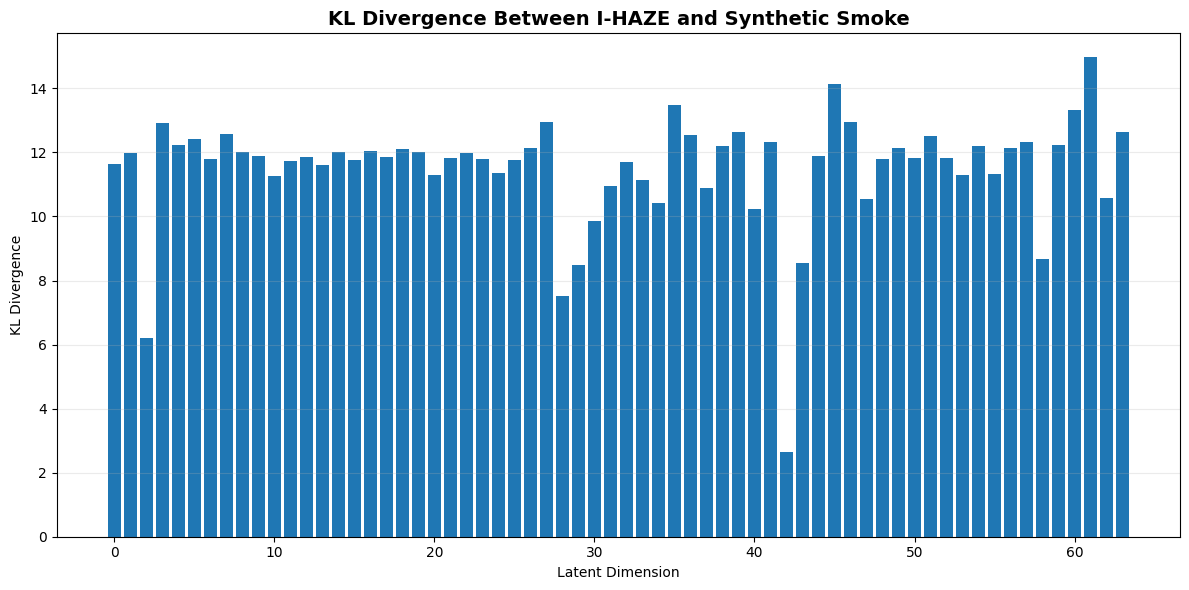

In [20]:
plt.figure(figsize=(12, 6))

plt.bar(
    np.arange(LATENT_DIM),
    kl_values
)

plt.xlabel(
    "Latent Dimension"
)

plt.ylabel(
    "KL Divergence"
)

plt.title(
    "KL Divergence Between I-HAZE and Synthetic Smoke",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

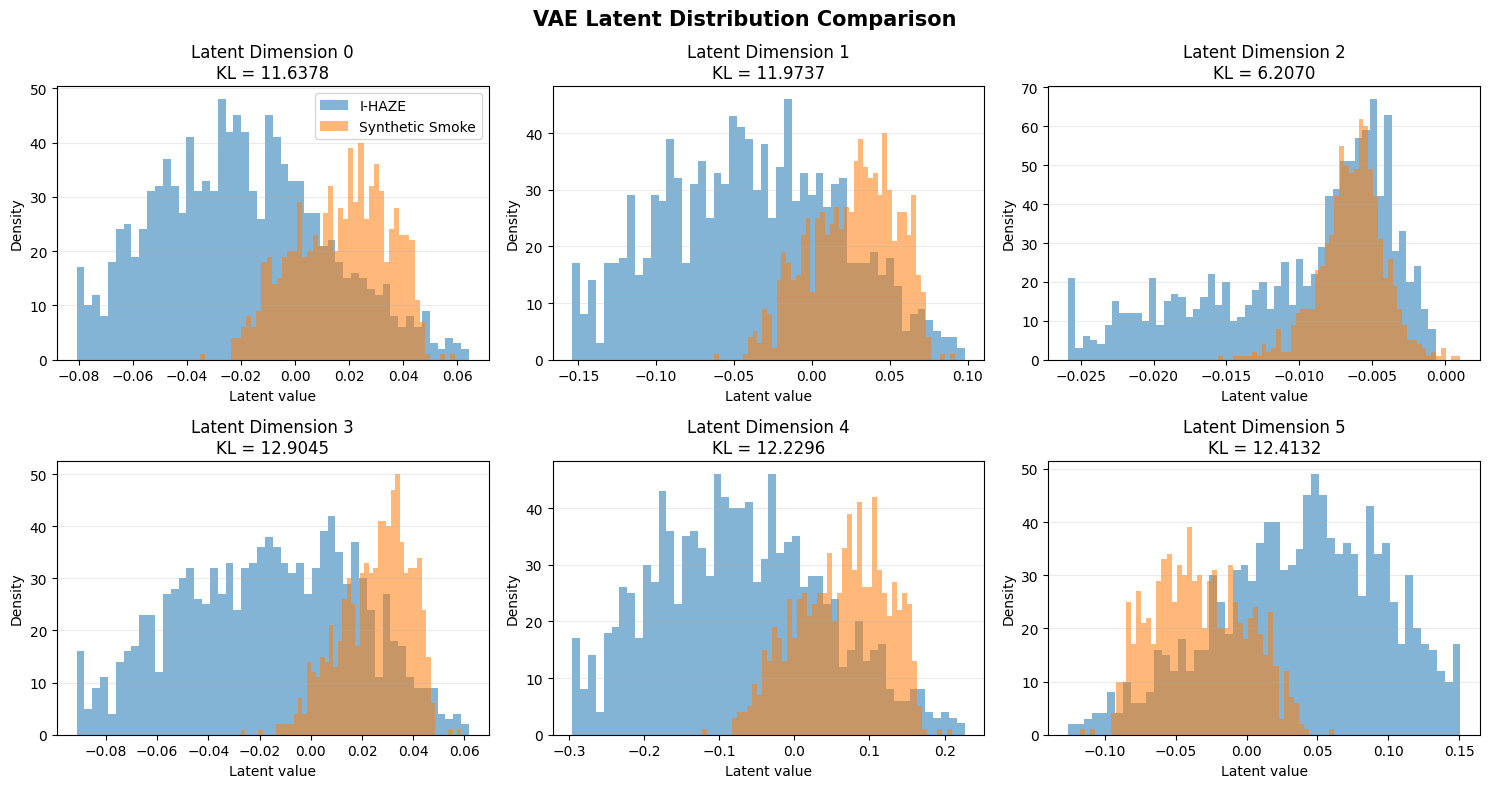

In [21]:
dimensions_to_plot = [
    0,
    1,
    2,
    3,
    4,
    5
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)


for ax, dim in zip(
    axes.flat,
    dimensions_to_plot
):

    ax.hist(
        ihaze_latent[:, dim],
        bins=50,
        density=False,
        alpha=0.55,
        label="I-HAZE"
    )


    ax.hist(
        smoky_latent[:, dim],
        bins=50,
        density=False,
        alpha=0.55,
        label="Synthetic Smoke"
    )


    ax.set_title(
        f"Latent Dimension {dim}\n"
        f"KL = {kl_values[dim]:.4f}"
    )


    ax.set_xlabel(
        "Latent value"
    )

    ax.set_ylabel(
        "Density"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )


axes[0, 0].legend()


plt.suptitle(
    "VAE Latent Distribution Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# PCA visualization

In [22]:
from sklearn.decomposition import PCA

In [23]:
combined_latent = np.vstack([
    ihaze_latent,
    smoky_latent
])

labels = np.array(
    ["I-HAZE"] * len(ihaze_latent)
    +
    ["Synthetic Smoke"] * len(smoky_latent)
)

In [24]:
pca = PCA(
    n_components=2
)

latent_2d = pca.fit_transform(
    combined_latent
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: [0.99839014 0.00104914]
Total explained: 0.9994393


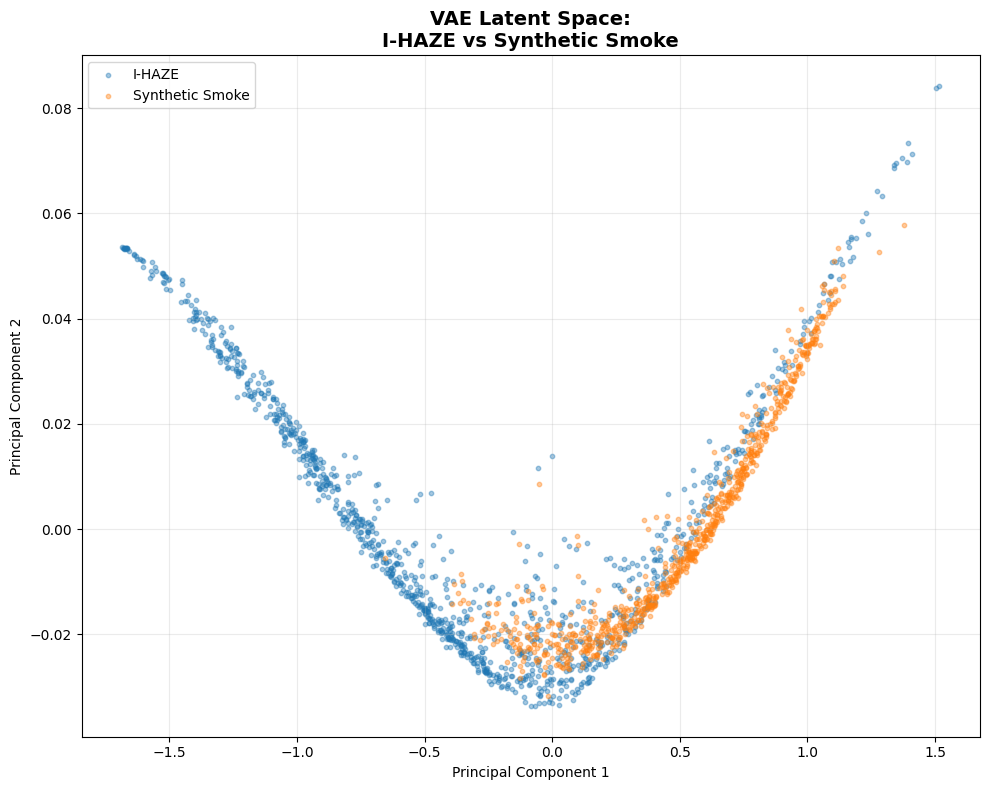

In [25]:
plt.figure(figsize=(10, 8))

ihaze_mask = (
    labels == "I-HAZE"
)

smoky_mask = (
    labels == "Synthetic Smoke"
)


plt.scatter(
    latent_2d[ihaze_mask, 0],
    latent_2d[ihaze_mask, 1],
    alpha=0.4,
    s=10,
    label="I-HAZE"
)


plt.scatter(
    latent_2d[smoky_mask, 0],
    latent_2d[smoky_mask, 1],
    alpha=0.4,
    s=10,
    label="Synthetic Smoke"
)


plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)


plt.title(
    "VAE Latent Space:\n"
    "I-HAZE vs Synthetic Smoke",
    fontsize=14,
    fontweight="bold"
)


plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()